# Customer Analytics: Online Retail II

Este notebook só **lê e mostra** o que o banco calculou (views do schema `analise`).
Nenhuma regra é recalculada aqui: limpeza, RFM, churn, coortes e CLV estão em SQL
versionado (`db/migracoes`) e testados (`tests/`). As decisões e os números estão em
[`docs/DECISOES.md`](../docs/DECISOES.md).

Pré-requisitos: `python -m varejo.carga` e `python -m varejo.processar`.

In [1]:
import pandas as pd
from IPython.display import display

from varejo import graficos
from varejo.banco import engine
from varejo.config import RAIZ_PROJETO, carregar_config_banco

motor = engine(carregar_config_banco())
IMG = RAIZ_PROJETO / "docs" / "img"
IMG.mkdir(parents=True, exist_ok=True)


def ler(consulta: str) -> pd.DataFrame:
    return pd.read_sql(consulta, motor)


def salvar(fig, nome: str) -> None:
    fig.savefig(IMG / f"{nome}.png")


pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## 0. Qualidade dos dados

Antes de qualquer número, as 18 checagens do schema `dq`. Todas precisam estar ok.

In [2]:
dq = ler("SELECT camada, verificacao, esperado, obtido, ok FROM dq.resultado ORDER BY camada, verificacao")
assert dq["ok"].all(), "há checagem de qualidade falhando"
dq

,camada,verificacao,esperado,obtido,ok
0,analise,analise_churn_validado_nos_dois_cortes,2,2,True
1,analise,analise_clientes_com_compra,5852,5852,True
2,analise,analise_clv_preenchido,0,0,True
3,analise,analise_coortes_receita_bate,16413300.877,16413300.877,True
4,analise,analise_coortes_somam_clientes,5852,5852,True
5,analise,analise_pedidos_somam_o_limpo,19057002.628,19057002.628,True
6,analise,analise_quintis_r_e_m,<= 1.10,1.03,True
7,analise,analise_receita_liquida_bate,16413300.877,16413300.877,True
8,bruto,bruto_formatos,0,0,True
9,bruto,bruto_linhas_da_ultima_carga,1067371,1067371,True


## 1. Visão geral

Receita de produto por mês, separando o que tem cliente identificado do que não tem
(essa parte não entra nas análises de cliente, mas é receita real).

,£
venda_produto_com_cliente,"17,124,941.00"
venda_produto_sem_cliente,"2,576,013.46"
cancelamento_produto,"-719,692.94"
receita_produto_liquida,"18,981,261.52"
frete_taxas_e_ajustes,"75,741.11"


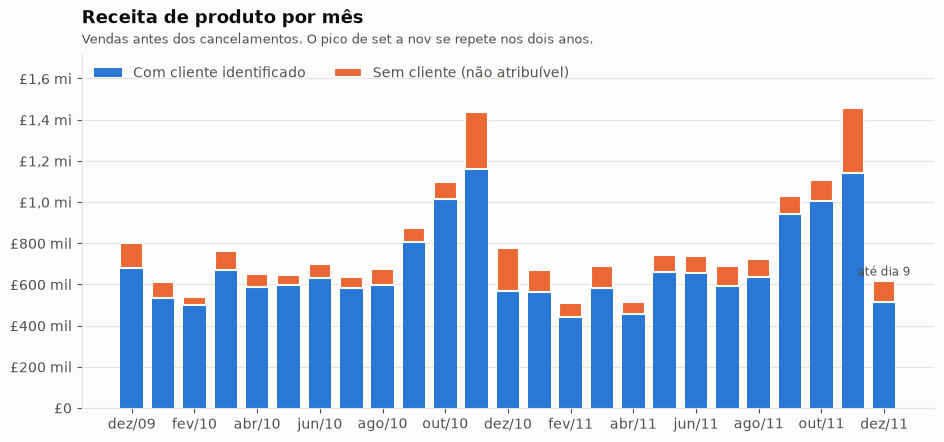

In [3]:
receita = ler("SELECT * FROM analise.vw_receita_mes ORDER BY mes")
fig = graficos.receita_mensal(receita)
salvar(fig, "receita_mensal")
totais = receita[["venda_produto_com_cliente", "venda_produto_sem_cliente",
                  "cancelamento_produto", "receita_produto_liquida", "frete_taxas_e_ajustes"]].sum()
totais.to_frame("£")

**Leitura:** a sazonalidade é forte e se repete: setembro a novembro concentram o
ano (nov/2010 e nov/2011 passam de £1,4 mi, contra £0,5 a £0,7 mi nos meses comuns).
Dez/2011 vai só até o dia 9. Cerca de 13% da receita de produto vem de vendas sem
cliente identificado.

## 2. Quem são os melhores clientes? (RFM)

Notas de 1 a 5 por `percent_rank` (empates com a mesma nota) e segmento pelo mapa R x F.

,segmento,clientes,pct_clientes,pct_receita,recencia_media,frequencia_media,ticket_medio,atacado
0,Campeões,1380,0.24,0.69,20.00,16.20,407.85,165
1,Leais,1196,0.20,0.15,76.00,5.60,359.24,124
2,Potenciais leais,271,0.05,0.01,25.00,2.00,352.91,29
3,Novos,72,0.01,0.00,11.00,1.00,339.10,14
4,Promissores,163,0.03,0.00,38.00,1.00,330.35,16
5,Precisam de atenção,425,0.07,0.01,107.00,1.40,380.55,66
6,Não pode perder,66,0.01,0.03,330.00,17.10,360.54,8
7,Em risco,647,0.11,0.06,362.00,4.30,328.40,49
8,Hibernando,673,0.12,0.02,314.00,1.40,315.18,50
9,Perdidos,959,0.16,0.02,552.00,1.30,324.85,86


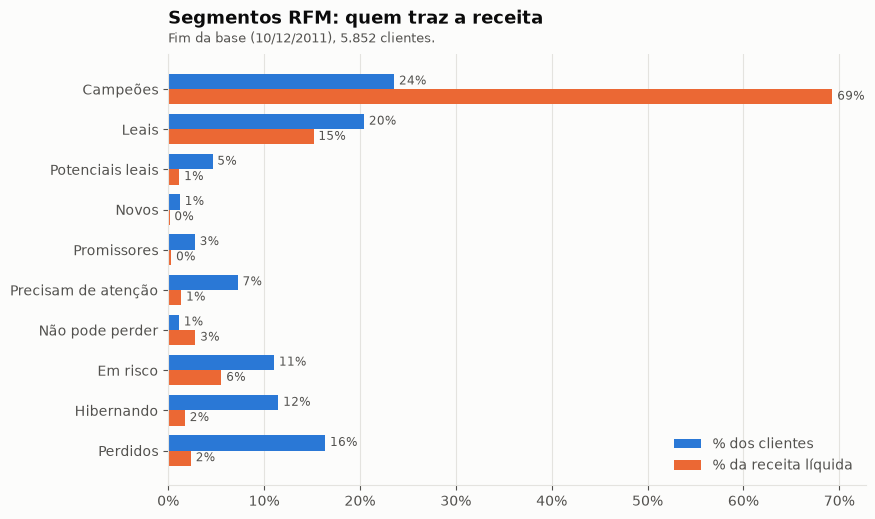

In [4]:
resumo = ler("SELECT * FROM analise.vw_segmento_resumo ORDER BY ordem")
fig = graficos.segmentos(resumo)
salvar(fig, "segmentos")
resumo[["segmento", "clientes", "pct_clientes", "pct_receita", "recencia_media",
        "frequencia_media", "ticket_medio", "atacado"]]

**Leitura:** os Campeões são 24% dos clientes e fazem 69% da receita líquida
atribuível (clientes identificados).
"Não pode perder" é pequeno (66 clientes), mas tem frequência média de 17 compras: é
a lista de contato pessoal do CRM.

In [5]:
clientes = ler("SELECT perfil, count(*) AS clientes, sum(receita_liquida) AS receita FROM analise.vw_cliente GROUP BY perfil")
clientes["pct_receita"] = clientes["receita"] / clientes["receita"].sum()
clientes

,perfil,clientes,receita,pct_receita
0,Varejo,5245,"10,171,390.34",0.62
1,Atacado,607,"6,241,910.54",0.38


## 3. Quem está indo embora? (churn)

Regra: mais de X dias sem comprar. Validada em dois cortes, só com o passado: o "real"
é não ter comprado nos 6 meses seguintes.

,corte,dias,marcados,precisao,recall,f1,acuracia,escolhido
0,2011-06-10,30,3907,0.56,0.93,0.70,0.62,False
1,2011-06-10,60,3375,0.61,0.87,0.71,0.67,False
2,2011-06-10,90,2971,0.64,0.80,0.71,0.69,True
3,2011-06-10,120,2666,0.67,0.75,0.71,0.70,False
4,2011-06-10,150,2441,0.68,0.70,0.69,0.70,False
5,2011-06-10,180,2306,0.69,0.67,0.68,0.70,False
6,2011-06-10,240,1350,0.78,0.44,0.56,0.67,False
7,2011-06-10,365,621,0.85,0.22,0.35,0.61,False
8,2010-12-10,30,2718,0.64,0.76,0.70,0.64,False
9,2010-12-10,60,1912,0.69,0.57,0.63,0.63,False


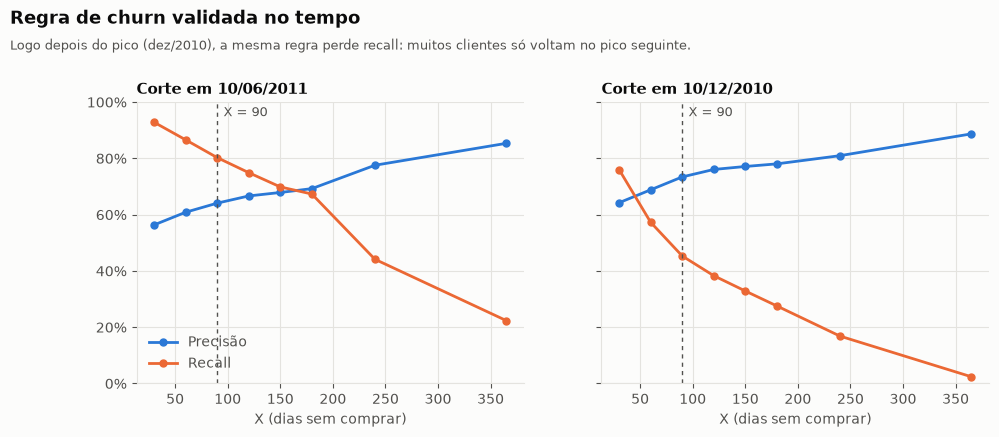

In [6]:
validacao = ler("SELECT * FROM analise.churn_validacao ORDER BY corte DESC, dias")
x = int(ler("SELECT valor FROM analise.parametro WHERE nome = 'churn_dias'").iloc[0, 0])
fig = graficos.validacao_churn(validacao, x)
salvar(fig, "validacao_churn")
validacao[["corte", "dias", "marcados", "precisao", "recall", "f1", "acuracia", "escolhido"]]

**Leitura:** no corte de junho o F1 é quase plano entre 30 e 120 dias (0,70 a
0,715); ficou X = 90 por ser fácil de agir. Dos marcados, 64% de fato não voltaram, e a
regra pegou 80% dos que não voltaram. Em dezembro, logo depois do pico, a mesma regra
perde recall (45%): muitos clientes só voltam no pico seguinte.

Onde está o sinal: a taxa de "não voltou" por faixa de recência (tabela abaixo) mostra
que quem está de 91 a 180 dias sem comprar não volta em 46% dos casos, praticamente a
taxa base (48%). A regra separa os ativos de quem já foi embora; por isso o fim da base
separa **em risco** (91 a 365 dias) de **inativo** (mais de um ano).

In [7]:
display(ler("SELECT corte, faixa, clientes, nao_voltaram, taxa_nao_voltou FROM analise.churn_faixa ORDER BY corte DESC, ordem"))
ler("""SELECT status_churn, count(*) AS clientes, round(sum(receita_12m)) AS receita_12m
    FROM analise.cliente GROUP BY status_churn ORDER BY status_churn""")

,corte,faixa,clientes,nao_voltaram,taxa_nao_voltou
0,2011-06-10,até 90 dias,1973,468,0.24
1,2011-06-10,91 a 180 dias,665,307,0.46
2,2011-06-10,181 a 365 dias,1685,1067,0.63
3,2011-06-10,mais de 365 dias,621,530,0.85
4,2010-12-10,até 90 dias,2867,1256,0.44
5,2010-12-10,91 a 180 dias,607,408,0.67
6,2010-12-10,181 a 365 dias,749,578,0.77
7,2010-12-10,mais de 365 dias,62,55,0.89


,status_churn,clientes,receita_12m
0,ativo,2885,"7,148,662.00"
1,em_risco,1376,"837,690.00"
2,inativo,1591,"-2,569.00"


## 4. A retenção melhora ou piora? (coortes)

,ativos,tamanho,retencao
meses_desde,,,
1,982,4682,0.21
3,901,4273,0.21
6,730,3957,0.18
12,606,3288,0.18


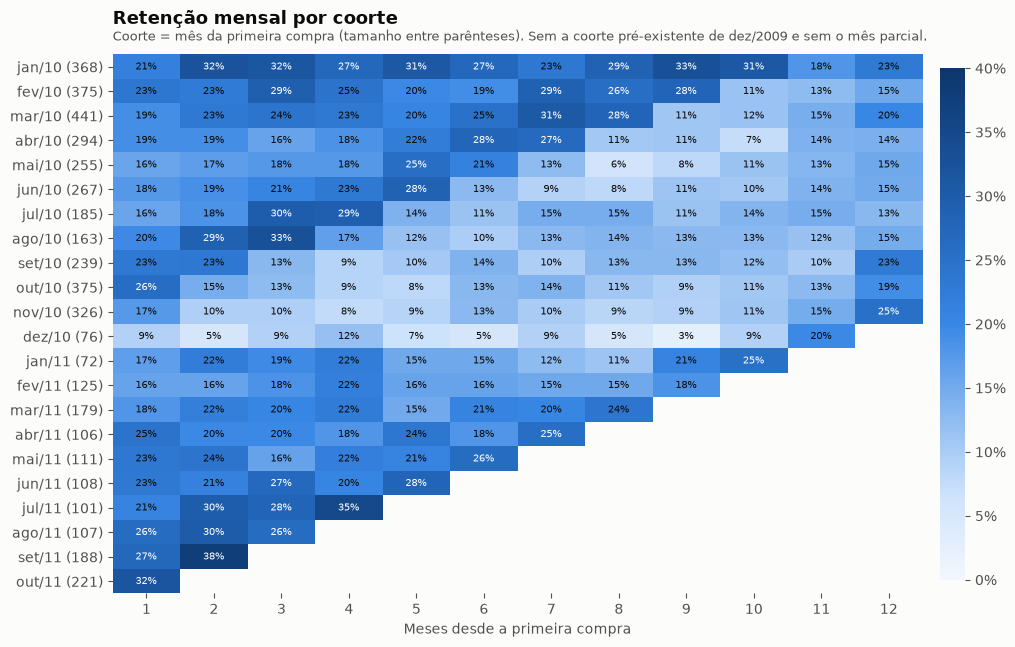

In [8]:
coortes = ler("SELECT * FROM analise.coorte_retencao")
fig = graficos.heatmap_coortes(coortes)
salvar(fig, "coortes")
sem_pre = coortes[~coortes["pre_existente"] & ~coortes["mes_parcial"]]
media = (sem_pre[sem_pre["meses_desde"].isin([1, 3, 6, 12])]
         .groupby("meses_desde")[["ativos", "tamanho"]].sum())
media["retencao"] = media["ativos"] / media["tamanho"]
media

**Leitura:** cerca de 1 em cada 5 clientes volta a comprar no mês seguinte (21%
no mês 1, 18% no mês 6). Comparar 2010 com 2011 é **inconclusivo**: as coortes do
começo de 2010 misturam clientes antigos que voltaram (censura à esquerda: ~70% dos
"novos" de jan a mar, medido com o análogo de 2011) e a sazonalidade mexe no mês 1. A
diagonal mais escura nas coortes de 2010 é o pico de set a nov do ano seguinte.

## 5. Quanto vale cada cliente? (CLV)

CLV previsto = p_ativo(segmento) x ticket médio x compras por mês x meses. Validado
com a previsão feita em 10/06/2011 contra a receita real até 10/12/2011.

,modelo,clientes,total_previsto,total_real,erro_total_pct,erro_medio_abs,captura_top20
0,ingenuo,4944,"3,005,615.24","4,243,517.70",-29.17,547.34,0.87
1,ingenuo_sazonal,4944,"4,743,631.74","4,243,517.70",11.79,649.91,0.84
2,previsto,4944,"4,253,046.66","4,243,517.70",0.22,603.18,0.88


,previsto,ingenuo_sazonal,ingenuo,real
segmento,,,,
Campeões,"2,582,372.83","3,121,278.97","2,293,333.02","3,117,946.63"
Leais,"680,583.13","762,986.28","427,752.78","521,410.12"
Potenciais leais,"126,733.06","28,372.58","104,965.33","94,082.51"
Novos,"57,119.96",0.00,"26,838.00","34,976.24"
Promissores,"124,907.37",-31.85,"72,712.92","62,488.43"
Precisam de atenção,"124,847.03","68,649.85","81,395.14","60,247.93"
Não pode perder,"37,926.88","67,911.49",0.00,"12,704.36"
Em risco,"211,513.67","302,127.77",-102.75,"136,733.17"
Hibernando,"187,951.70","307,421.39",-463.59,"140,322.45"


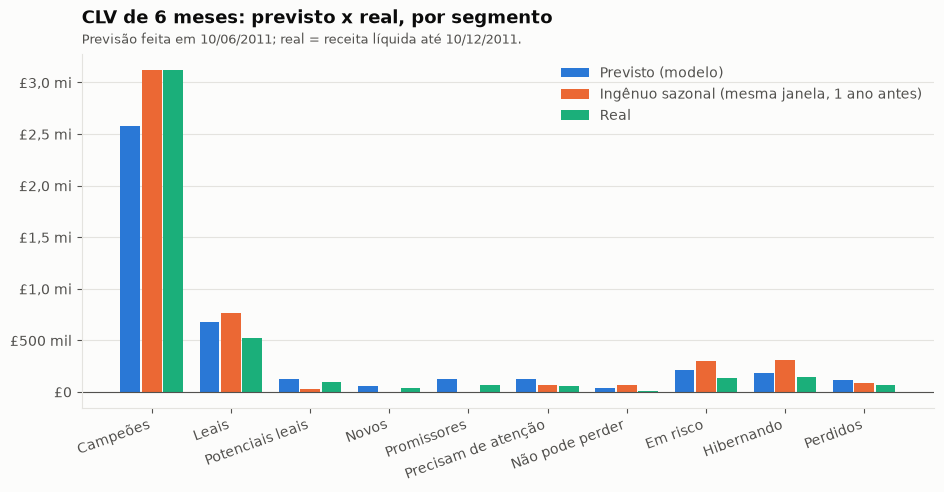

In [9]:
resumo_clv = ler("SELECT * FROM analise.clv_validacao")
display(resumo_clv)
validacao_clv = ler("SELECT * FROM analise.clv_validacao_cliente")
ordem = resumo.sort_values("ordem")["segmento"].tolist()
fig = graficos.clv_previsto_vs_real(validacao_clv, ordem)
salvar(fig, "clv_validacao")
validacao_clv.groupby("segmento")[["previsto", "ingenuo_sazonal", "ingenuo", "real"]].sum().reindex(ordem)

**Leitura:** o modelo ganha do ingênuo sazonal ("repete a mesma janela de um ano
antes") nas três medidas: erro no total +0,2% contra +11,8%, erro médio £603 contra
£650, captura do top 20% 0,882 contra 0,845. Mas o total fecha em parte porque os erros
se compensam: por segmento, o viés vai de -17% (Campeões, subestimados) a +199% (Não
pode perder). O b da suavização foi escolhido nesse mesmo corte. Detalhes em DECISOES
D23 e D24.

In [10]:
ler("""SELECT round(sum(clv_previsto_6m)) AS clv_6m_total,
           round(avg(clv_previsto_6m)) AS media,
           round(percentile_cont(0.5) WITHIN GROUP (ORDER BY clv_previsto_6m)) AS mediana
    FROM analise.cliente""")

,clv_6m_total,media,mediana
0,"3,822,972.00",653.00,223.00
